In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("2025-12-23_08-54-28-772.csv")
df.head()

,CH1,CH2,time,Ts
0,-99.968750,0.019984,0.000000e+00,4.000000e-09
1,-97.984375,0.023953,4.000000e-09,NaN
2,-94.000000,0.024000,8.000000e-09,NaN
3,-100.000000,0.023953,1.200000e-08,NaN
4,-108.000000,0.021891,1.600000e-08,NaN


In [3]:
V0corr= pd.read_csv(r"../02_Power_spp_11V_Tny264_V2/2025-12-21_13-59-23-559.csv").CH1.mean()
V0corr

np.float64(-21.3888)

In [4]:
from utils import *
trigger

<function utils.trigger(sig, thresh=None, transition='rise', marginI=20)>

In [5]:
from sklearn.linear_model import LinearRegression as LR

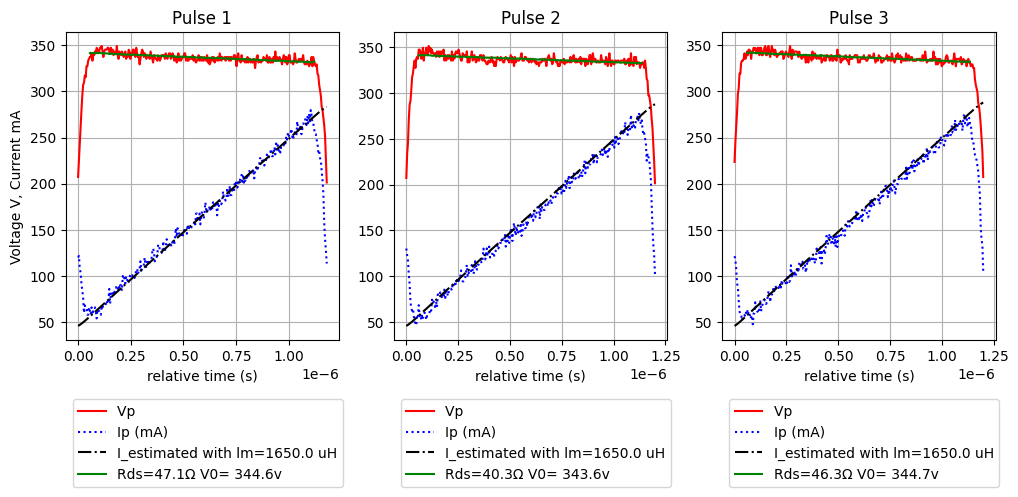

In [6]:
fig , axs = plt.subplots(1,3, figsize=(12,4))
axs = axs .flatten()

## df= pd.read_csv("2025-12-23_08-54-28-772.csv")
Ts = df.Ts .values[0]
Vp = df.CH1.values-V0corr
Ip = df.CH2.values
time = df.time.values
irise = trigger(Vp, 200,'rise')
ifall = trigger(Vp, 200,'fall')
Vin =340
k=1
colors=["C0","C1","C2"]
for i,j in zip(irise, ifall):
    N=500
    t=time[i-N:j]
    t=t-t[0]
    vp=Vp[i-N:j]
    ip=Ip[i-N:j]
    ip=ip-ip[:50].mean()
    t=t[N:]
    ip=ip[N:]
    vp=vp[N:]
    t=t-t[0]
    axs[k-1].plot(t,vp, label =f"Vp ", c=f"r")
    axs[k-1].plot(t,ip*1e3, label =f"Ip (mA)", linestyle="dotted", c=f"b")
    # v =L di/dt
    Lm=1650e-6
    ical= vp.cumsum()*Ts/Lm
    axs[k-1].plot(t,1e3*ical+45, c=f"k", label=f"I_estimated with lm={1e6*Lm:0.1f} uH"
             , linestyle='dashdot')
    axs[k-1].set_title(f"Pulse {k}")
    axs[k-1].grid()

    N=len(ip)
    ip = ip[int(0.05*N):int(0.95*N)]
    vp = vp[int(0.05*N):int(0.95*N)]
    x = ip.reshape(-1,1)
    y=vp
    model = LR().fit(x,y)
    Rds = -model.coef_
    V0= model.intercept_
    axs[k-1].plot(t[int(0.05*N):int(0.95*N)], V0-Rds*x, 
                  label = f"Rds={Rds[0]:0.1f}Ω V0= {V0:0.1f}v", 
                 c="g")
    #axs[k-1].legend()
    axs[k-1].legend(loc='lower left', bbox_to_anchor=(0, -0.5))
    axs[k-1].set_xlabel ("relative time (s)")

    


    
    k=k+1
axs[0].set_ylabel ("Voltage V, Current mA")
    
time = np.arange(0, len(Vp)*Ts, Ts)
fig.savefig("Tny264_345V_lm.png", bbox_inches="tight")



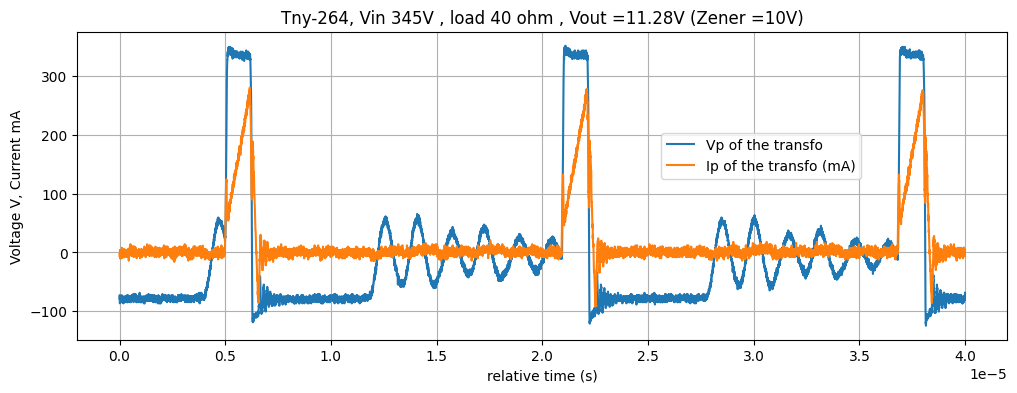

In [7]:
df= pd.read_csv("2025-12-23_08-54-28-772.csv")
Ts = df.Ts .values[0]
Vp = df.CH1.values-V0corr
Ip = df.CH2.values
Ip = Ip-Ip[:500].mean()


time = np.arange(0, len(Vp)*Ts, Ts)
fig , axs = plt.subplots(1,1, figsize=(12,4))
plt.plot(time, Vp, label = "Vp of the transfo")
plt.plot(time, 1000*Ip, label = "Ip of the transfo (mA)")
plt.grid()
plt.legend(ncols=1,loc='lower right', bbox_to_anchor=(0.85, 0.5))
plt.ylabel ("Voltage V, Current mA")
plt.xlabel ("relative time (s)")
plt.title("Tny-264, Vin 345V , load 40 ohm , Vout =11.28V (Zener =10V)")
fig.savefig("Tny264_345V_time.png", bbox_inches="tight")

In [8]:
from math import *

In [9]:
from copy import copy
Vp0=copy(Vp )

0.6329113924050632 MHZ
6.060606060606056 MHZ


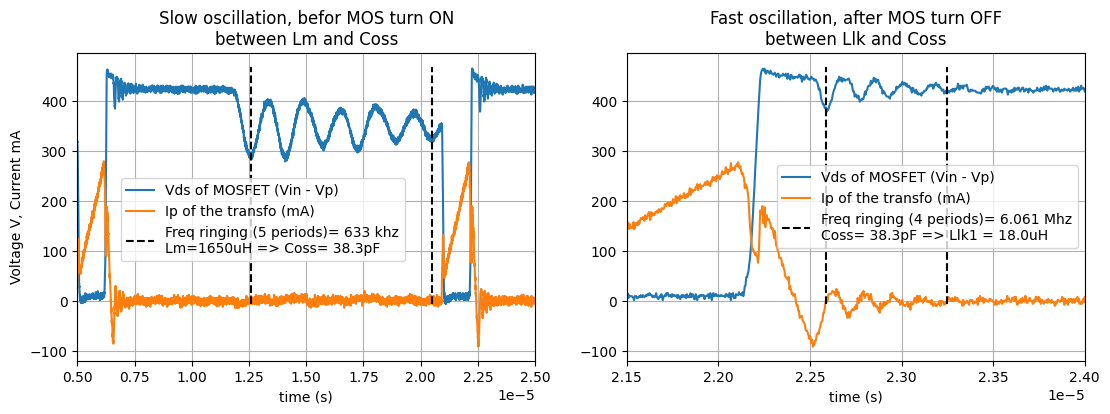

In [10]:
fig , axs = plt.subplots(1,2, figsize=(13,4))
axs = axs .flatten()
vin = 345

Vp=vin-copy(Vp0)
################
plt.sca(axs[0])

plt.plot(time, Vp, label = "Vds of MOSFET (Vin - Vp)")
Ip2= Ip-Ip[:200].mean()
plt.plot(time, 1000*Ip2, label = "Ip of the transfo (mA)")
plt.xlim([0.5e-5,2.5e-5])
x0=1.26e-5
x1=2.05e-5
plt.plot([x0,x0],[Vp.min(), Vp.max()], c="k", linestyle="--")


n=5
fring= n/(x1-x0)
print(fring*1e-6, "MHZ")
fring_lm= fring
Lm=1650
Coss= 1/ ((2*pi)**2*Lm*1e-6*fring_lm**2)

plt.plot([x1,x1],[Vp.min(), Vp.max()], c="k", linestyle="--",
         label = f"Freq ringing ({n} periods)= {fring*1e-3:.0f} khz"+\
         f"\nLm={Lm}uH => Coss= {Coss*1e12:0.1f}pF")


plt.grid()
plt.legend()
plt.title("Slow oscillation, befor MOS turn ON\nbetween Lm and Coss")



##################
plt.sca(axs[1])

plt.plot(time, Vp, label = "Vds of MOSFET (Vin - Vp)")
Ip2= Ip-Ip[:200].mean()
plt.plot(time, 1000*Ip2, label = "Ip of the transfo (mA)")
plt.xlim([0.6e-5,0.8e-5])
plt.xlim([2.15E-5,2.4E-5])
x0=2.259e-5
x1=2.325e-5
plt.plot([x0,x0],[Vp.min(), Vp.max()], c="k", linestyle="--")


n=4
fring= n/(x1-x0)
print(fring*1e-6, "MHZ")
Llk1 = 1/ ((2*pi)**2*Coss*fring**2)
plt.plot([x1,x1],[Vp.min(), Vp.max()], c="k", linestyle="--",
         label = f"Freq ringing ({n} periods)= {fring*1e-6:.3f} Mhz\n"+\
        f"Coss= {Coss*1e12:0.1f}pF => Llk1 = {Llk1*1e6:.1f}uH")
fring_lk= fring

plt.grid()
plt.legend()
plt.title("Fast oscillation, after MOS turn OFF\nbetween Llk and Coss")

axs[0].set_ylabel ("Voltage V, Current mA")
axs[0].set_xlabel ("time (s)")
axs[1].set_xlabel ("time (s)")

axs[0].legend(loc='lower left', bbox_to_anchor=(0.08, 0.3))
fig.savefig("Tny264_345V_Llk_coss.png", bbox_inches="tight")

In [11]:
from math import *
C=2E-12
# Drain capa https://www.datasheet.live/pdfviewer?url=https%3A%2F%2Fpdf.datasheet.live%2F4fdce51b%2Fpowerint.com%2FTNY266PN.pdf
# i must take all parasite capa 
#fring=1/(2*pi*sqrt(LC))
Ls = 1/ ((2*pi)**2*C*fring**2)
print( Ls*1e6, "uH")

344.80865308283114 uH


In [12]:
from math import *
C=10e-9
#fring=1/(2*pi*sqrt(LC))
Ls = 1/ ((2*pi)**2*C*fring**2)
print( Ls*1e6, "uH")
# 0.63MHz is known as the DCM (Discontinuous Conduction Mode) Ringing.
# 6 Mhz is Leakage Ringing,

0.06896173061656623 uH


In [13]:
Lm =1700e-6
Np = 26
Ns=4
Ls = Lm *(Ns/Np)**2
Ls*1e6

40.23668639053255

In [14]:
Lm =1700e-6
Cnode = 1/ ((2*pi)**2*Lm*fring**2)
print("Drain Cnode", Cnode*1e12, "pF")



Fring0 = 6.17283950617284e6 # MHZ turn off
Ls = 1/ ((2*pi)**2*Cnode*Fring0**2)
print("Ls", Ls*1e6, "uH")
print("Leakage", 1e2*Ls/Lm, "%")
# 1% is typical for planner trans

Drain Cnode 0.4056572389209778 pF
Ls 1638.7438016528909 uH
Leakage 96.39669421487594 %


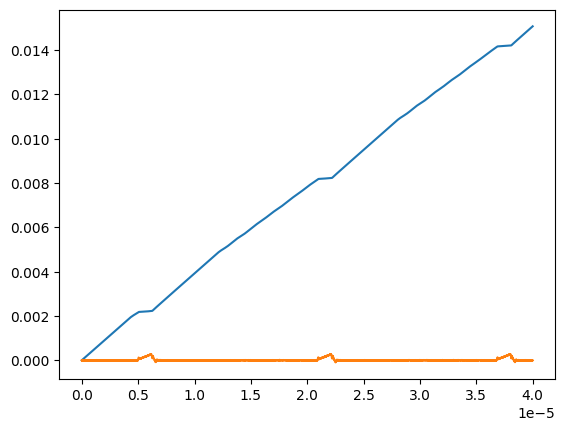

In [15]:
#scipy.integrate.cumtrapz(y, x=None, dx=1.0, axis=-1, initial=None)[source]
import  scipy
integVp = scipy.integrate.cumulative_trapezoid(y= Vp, dx=Ts,initial=0)
a= 26
integVp =integVp +a*time
integVp=integVp-integVp.min()
plt.plot(time, integVp )
plt.plot(time, Ip*1e-3)

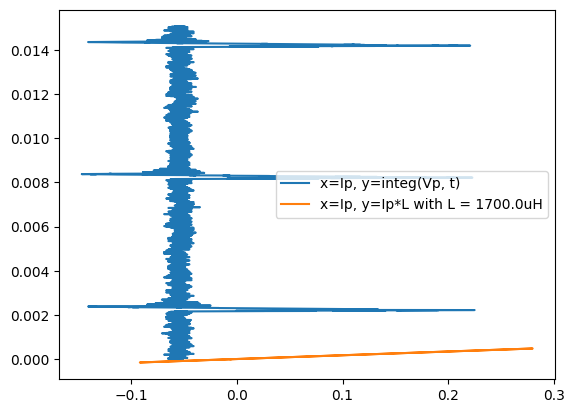

In [16]:
plt.plot(Ip-0.055, integVp,label =  "x=Ip, y=integ(Vp, t)")
L = 1700e-6
# v = L di/dt
# L i = integ(v,t)
plt.plot(Ip, Ip*L,label =  f"x=Ip, y=Ip*L with L = {1e6*L}uH")
plt.legend()

In [17]:
Ls/L

0.9639669421487593

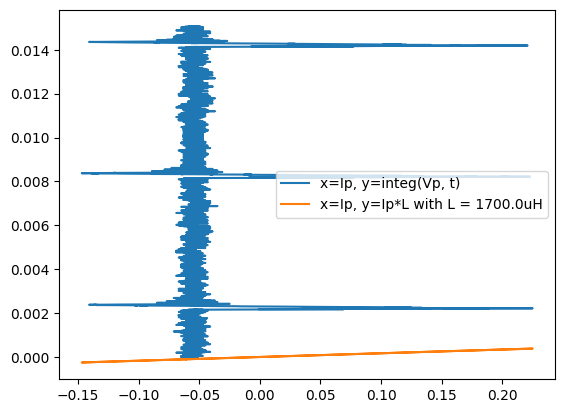

In [18]:
Ip2= Ip-0.055
plt.plot(Ip2 , integVp,label =  "x=Ip, y=integ(Vp, t)")
L = 1700e-6
# v = L di/dt
# L i = integ(v,t)
plt.plot(Ip2, Ip2*L,label =  f"x=Ip, y=Ip*L with L = {1e6*L}uH")
plt.legend()

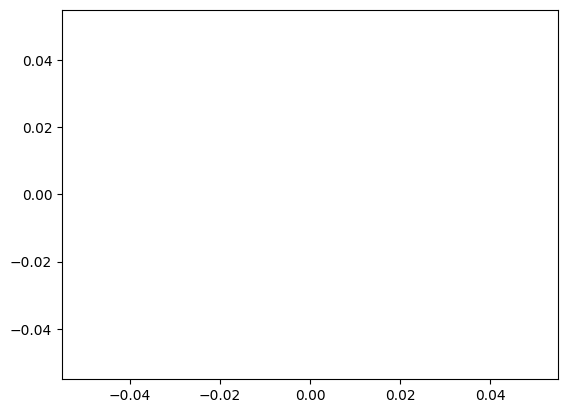

In [19]:
thresh=3e-5
index = [i for i in range(len(integVp)) 
         if np.abs(integVp[i]- (Ip2*L)[i])<thresh]


plt.scatter(Ip2 [index], integVp[index],
            label =  "x=Ip, y=integ(Vp, t)")
plt.plot(Ip2[index], (Ip2*L) [index],
         label =  f"x=Ip, y=Ip*L with L = {1e6*L}uH", c="C1")

In [20]:
5.2*26**2

3515.2000000000003

In [21]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

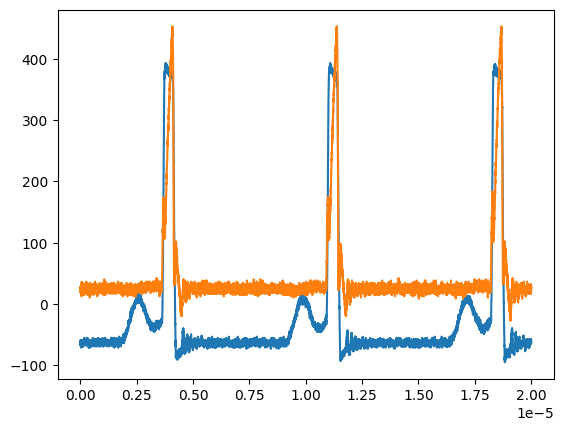

In [22]:
df= pd.read_csv("2025-12-23_08-56-59-168.csv")
Ts = df.Ts .values[0]
Vp = df.CH1.values
Ip = df.CH2.values

time = np.arange(0, len(Vp)*Ts, Ts)
plt.plot(time, Vp)
plt.plot(time, 1000*Ip)


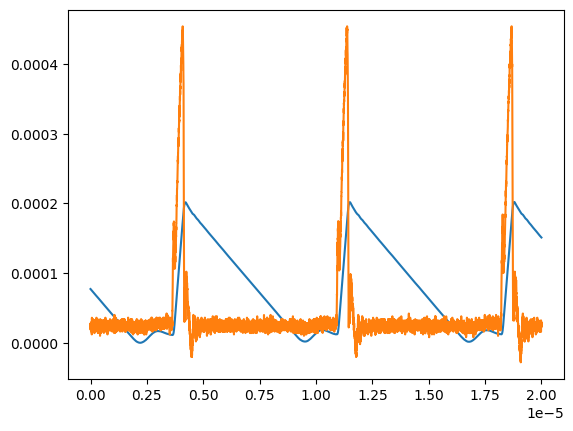

In [23]:
#scipy.integrate.cumtrapz(y, x=None, dx=1.0, axis=-1, initial=None)[source]
import  scipy
integVp = scipy.integrate.cumulative_trapezoid(y= Vp, dx=Ts,initial=0)
a= 26
integVp =integVp +a*time
integVp=integVp-integVp.min()
plt.plot(time, integVp )
plt.plot(time, Ip*1e-3)

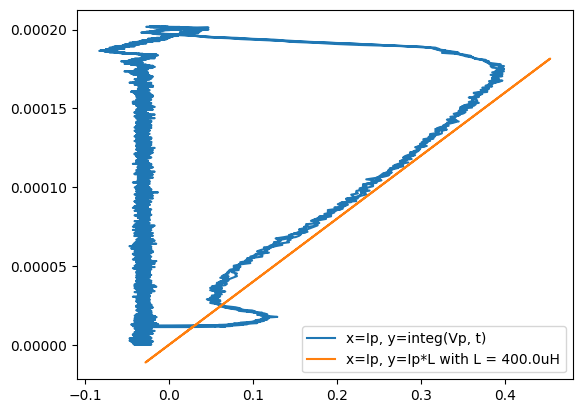

In [24]:
plt.plot(Ip-0.055, integVp,label =  "x=Ip, y=integ(Vp, t)")
L = 400e-6
# v = L di/dt
# L i = integ(v,t)
plt.plot(Ip, Ip*L,label =  f"x=Ip, y=Ip*L with L = {1e6*L}uH")
plt.legend()

np.float64(2e-09)

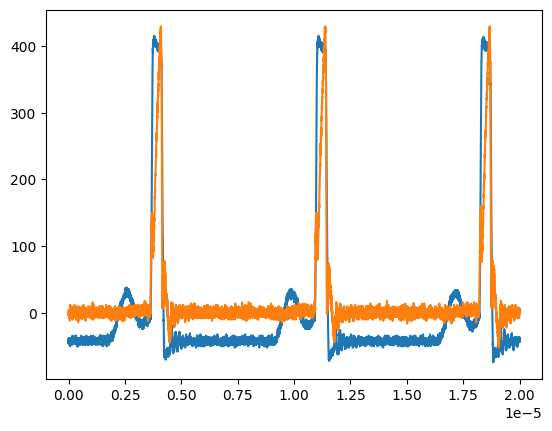

In [25]:
df= pd.read_csv("2025-12-23_08-56-59-168.csv")
Ts = df.Ts .values[0]
Vp = df.CH1.values
Ip = df.CH2.values

time = np.arange(0, len(Vp)*Ts, Ts)


Ip = Ip-Ip[:200].mean()
V0corr=-21.3888
Vp=Vp-V0corr

plt.plot(time, Vp)
plt.plot(time, 1000*Ip)
Ts

In [26]:
from utils import trigger
trigger

<function utils.trigger(sig, thresh=None, transition='rise', marginI=20)>

In [27]:
riseI = trigger(Vp, transition='rise')
fallI = trigger(Vp, transition='fall')
riseI , fallI 

([1843, 5487, 9133], [2080, 5725, 9371])

237
238
238


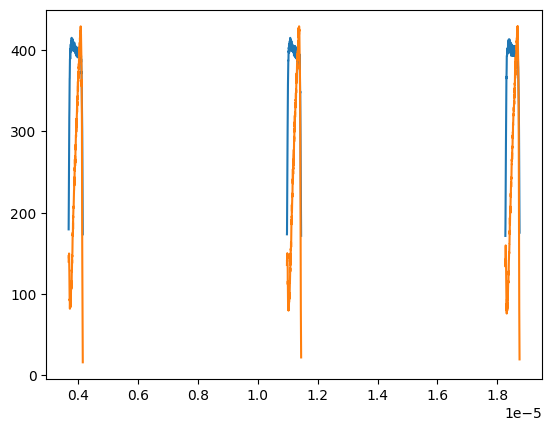

In [28]:
for (i,j) in zip(riseI , fallI ):
    plt.plot(time[i:j],Vp[i:j], c="C0")
    plt.plot(time[i:j],1e3*Ip[i:j], c="C1")
    print(j-i)

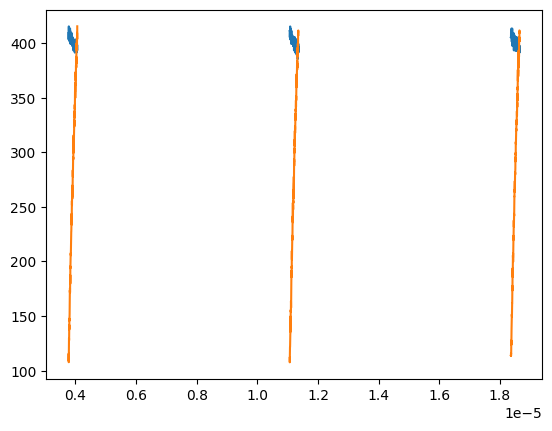

In [29]:
for (i,j) in zip(riseI , fallI ):
    N=j-i
    i=i+int(0.2*N)
    j=j-int(0.2*N)
    plt.plot(time[i:j],Vp[i:j], c="C0")
    plt.plot(time[i:j],1e3*Ip[i:j], c="C1")

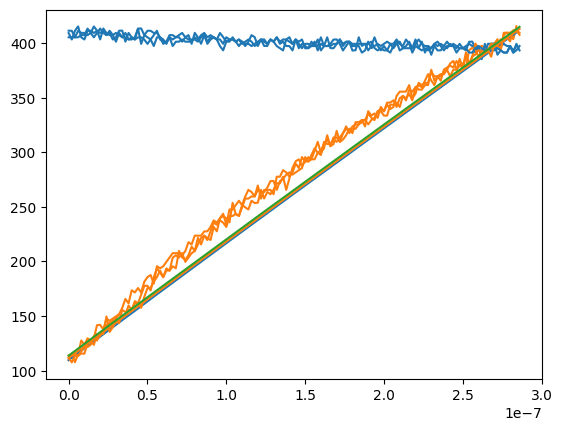

In [30]:
for (i,j) in zip(riseI , fallI ):
    N=j-i
    i=i+int(0.2*N)
    j=j-int(0.2*N)
    t=time[i:j]
    t=t-t[0]
    v=Vp[i:j]
    i=Ip[i:j]
    plt.plot(t,v, c="C0")
    plt.plot(t,1e3*i, c="C1")
    Np=26
    flux = v.cumsum()*Ts
    Lm=380e-6
    ical=(flux )/Lm
    ical = ical -ical[0]+i[0]
    plt.plot(t,1e3*ical)

In [31]:
Ts, 2e-6*10/10e3

(np.float64(2e-09), 1.9999999999999997e-09)

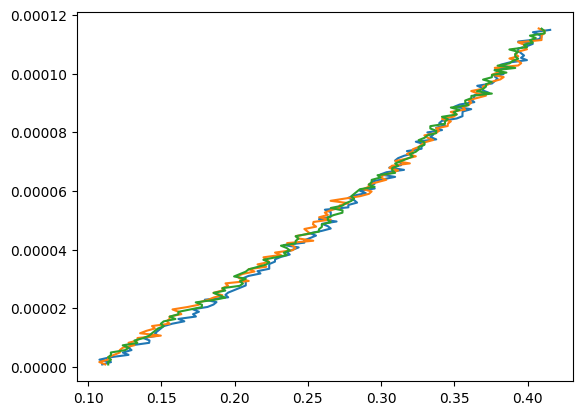

In [32]:
for (i,j) in zip(riseI , fallI ):
    N=j-i
    i=i+int(0.2*N)
    j=j-int(0.2*N)
    t=time[i:j]
    t=t-t[0]
    v=Vp[i:j]
    ic=Ip[i:j]
    #plt.plot(t,v, c="C0")
    #plt.plot(t,1e3*ic, c="C1")
    Np=26
    flux = v.cumsum()*Ts
    Lm=380e-6
    ical=(flux )/Lm
    ical = ical -ical[0]+ic[0]

    plt.plot(ic, flux)

# TNY264 48V

In [33]:
# Vin out 350.6 11.28
# 2026-01-03_20-43-43-679.csv
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

,CH2,CH3,CH4,time,Ts
0,-0.007,1.9,57.6,0.000000e+00,1.000000e-08
1,-0.008,2.3,57.6,1.000000e-08,NaN
2,-0.007,1.7,58.8,2.000000e-08,NaN
3,-0.011,2.2,57.6,3.000000e-08,NaN
4,-0.010,2.3,57.6,4.000000e-08,NaN


np.float64(1e-08)

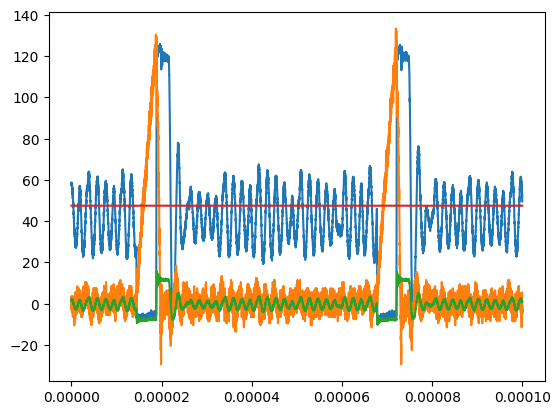

In [83]:
df= pd.read_csv("2026-01-03_20-13-08-982.csv")
display(df.head())
Ts = df.Ts .values[0]
#Vp = 47.5-df.CH4.values
Vds = df.CH4.values
Ip = df.CH2.values
Vs = df.CH3.values
vin = 47.5
time = np.arange(0, len(Vds)*Ts, Ts)


Ip = Ip-Ip[:200].mean()
#V0corr=-21.3888
#Vp=Vp-V0corr
#Vds=Vds+5
plt.plot(time, Vds)

plt.plot(time, 1000*Ip)
plt.plot(time, Vs)
plt.plot(time, len(time)*[vin ])
Ts

43.400000000000006


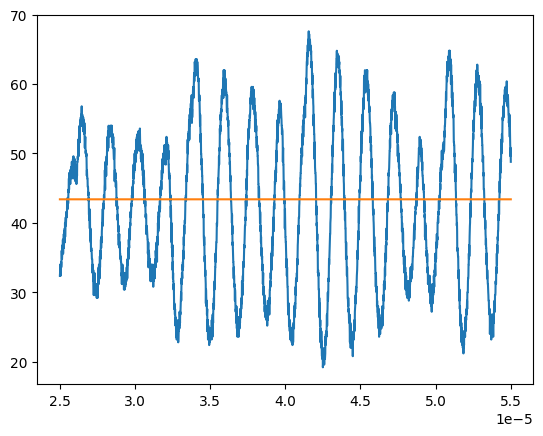

In [84]:
m= abs(time-40e-6)<15e-6
t= time[m]
v = Vds[m]
v0=(v.max()+v.min())/2
plt.plot(t,v )
plt.plot(t,len(t)*[v0] )
print(v0)

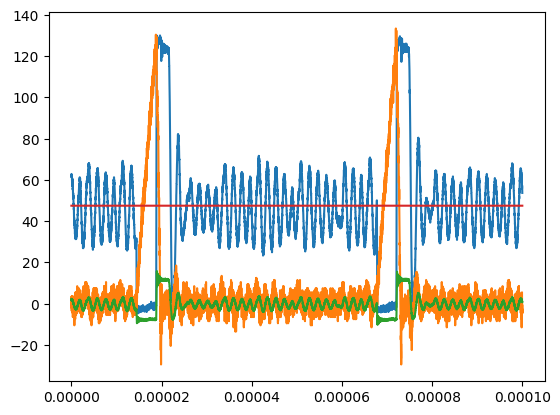

In [85]:
vds2=Vds-v0+vin
vp= vin -vds2
plt.plot(time, vds2)

plt.plot(time, 1000*Ip)
plt.plot(time, Vs)
plt.plot(time, len(time)*[vin ])

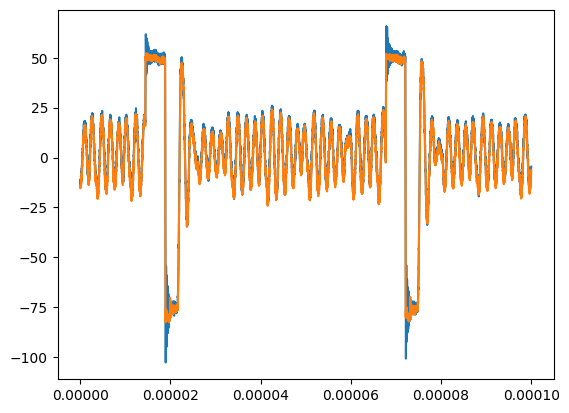

In [86]:
plt.plot(time, -Vs*26/4)
plt.plot(time, vp)

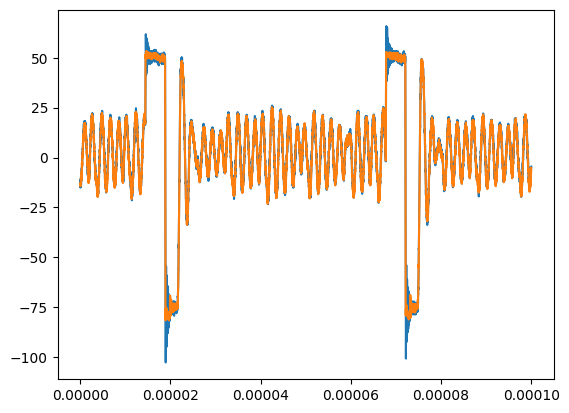

In [87]:
plt.plot(time, -Vs*26/4)
Vp = vp+1
plt.plot(time,Vp )

0.5675999999999999


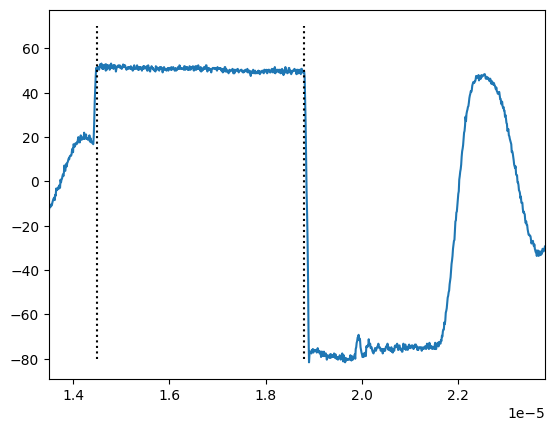

In [88]:
plt.plot(time,Vp ,label = "Vp of the transfo = Vin - Vds (v)")
t0=14.5e-6
t1=18.8e-6# 21.6e-6
plt.plot([t0,t0], [-80,70], c="k", linestyle= "dotted")
plt.plot([t1,t1], [-80,70], c="k", linestyle= "dotted")
plt.xlim([t0-1e-6,t1+5e-6])
dt=t1-t0
D= dt*132e3
print(D)

0.5675999999999999


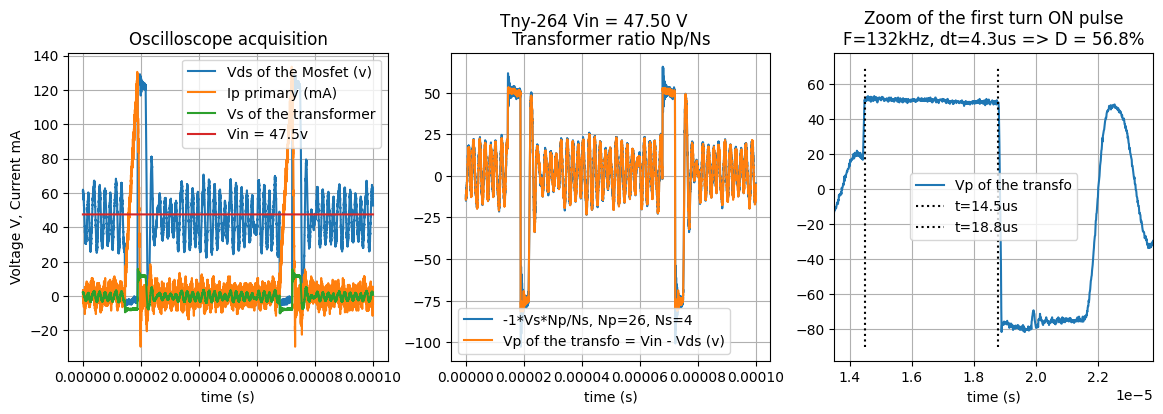

In [90]:
fig , axs = plt.subplots(1,3, figsize=(14,4))
axs = axs .flatten()

################
plt.sca(axs[0])

plt.plot(time, vin -Vp, label = "Vds of the Mosfet (v)")
plt.plot(time, 1000*Ip, label = "Ip primary (mA)")
plt.plot(time, Vs, label = "Vs of the transformer")
plt.plot(time, len(time)*[vin ], label = f"Vin = {vin}v")
plt.legend()
plt.grid()
plt.title('Oscilloscope acquisition')


plt.sca(axs[1])
plt.plot(time, -Vs*26/4,label = "-1*Vs*Np/Ns, Np=26, Ns=4")
plt.plot(time,Vp ,label = "Vp of the transfo = Vin - Vds (v)")
plt.legend()
plt.grid()
plt.title('Transformer ratio Np/Ns')





plt.sca(axs[2])
plt.plot(time,Vp ,label = "Vp of the transfo")
t0=14.5e-6
t1=18.8e-6# 21.6e-6
plt.plot([t0,t0], [-90,70], c="k", linestyle= "dotted",
         label = f"t={t0*1e6}us")
plt.plot([t1,t1], [-90,70], c="k", linestyle= "dotted", 
         label = f"t={t1*1e6}us")
plt.xlim([t0-1e-6,t1+5e-6])

plt.legend()
plt.grid()
dt=t1-t0
D= dt*132e3
print(D)
plt.title(f'Zoom of the first turn ON pulse\n'+\
          f'F=132kHz, dt={1e6*dt}us => D = {100*D:.1f}%')



axs[0].set_ylabel ("Voltage V, Current mA")
axs[0].set_xlabel ("time (s)")
axs[1].set_xlabel ("time (s)")
axs[2].set_xlabel ("time (s)")






#axs[0].legend(loc='lower left', bbox_to_anchor=(0.08, 0.3))
fig.suptitle("Tny-264 Vin = 47.50 V")
fig.savefig("Tny264_48V_time.png", bbox_inches="tight")


In [91]:
axs[0].cla()
plt.sca(axs[0])

In [92]:
from utils import trigger
trigger

<function utils.trigger(sig, thresh=None, transition='rise', marginI=20)>

In [93]:
riseI = trigger(Vp, transition='rise', thresh=60)
fallI = trigger(Vp, transition='fall', thresh=60)
riseI= riseI [:1]
fallI = fallI [:1]

In [94]:
fig = plt.gcf()
axs = fig.axes
plt.sca(axs[0])


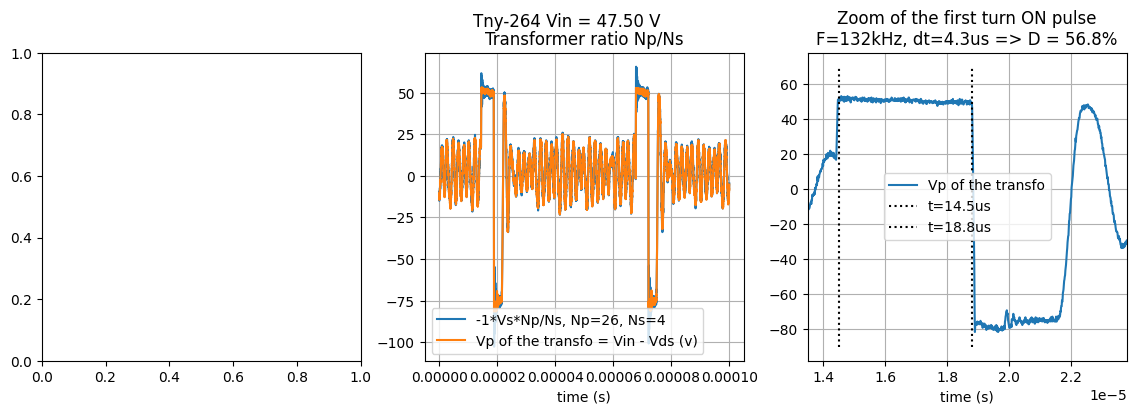

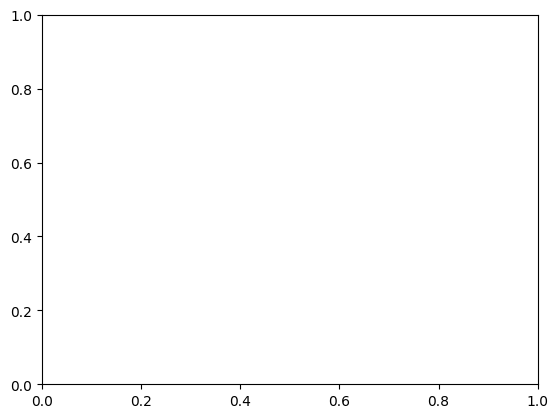

In [95]:
#fig = plt.gcf()
fig, axs = plt.subplots(1,1)
plt.sca(axs)

for (i,j) in zip(riseI , fallI ):
    axs[0].plot(time[i:j],Vp[i:j], c="C0")
    axs[0].plot(time[i:j],1e3*Ip[i:j], c="C1")
    print(j-i)

In [96]:
for (i,j) in zip(riseI , fallI ):
    N=j-i
    i=i+int(0.2*N)
    j=j-int(0.2*N)
    plt.plot(time[i:j],Vp[i:j], c="C0")
    plt.plot(time[i:j],1e3*Ip[i:j], c="C1")

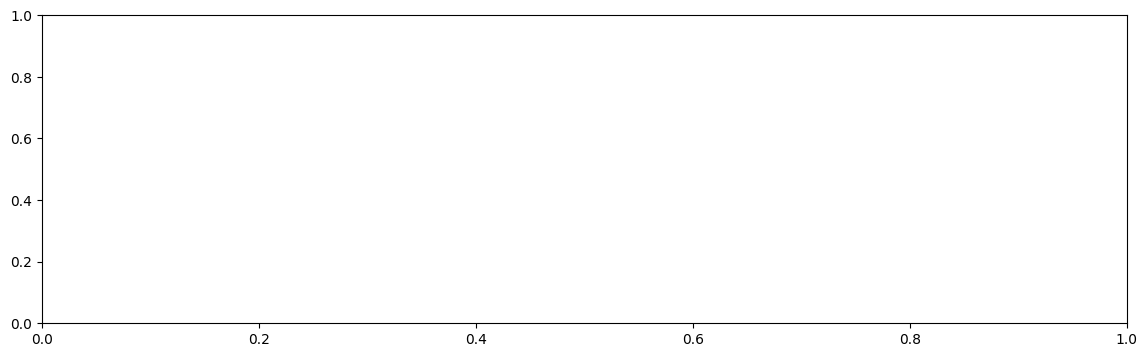

In [97]:
fig , axs = plt.subplots(1,1, figsize=(14,4))
for (i,j) in zip(riseI , fallI ):
    N=j-i
    i=i+int(0.2*N)
    j=j-int(0.2*N)
    t=time[i:j]
    t=t-t[0]
    v=Vp[i:j]
    i=Ip[i:j]
    plt.plot(t,v, c="C0")
    plt.plot(t,1e3*i, c="C1")
    Np=26
    flux = v.cumsum()*Ts
    Lm=2600E-6
    ical=(flux )/Lm
    ical = ical -ical[0]+i[0]
    plt.plot(t,1e3*ical)
plt.show()

# TNY280

In [98]:
# Vin out 350.6 11.28
# 2026-01-03_20-43-43-679.csv
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

np.float64(2e-09)

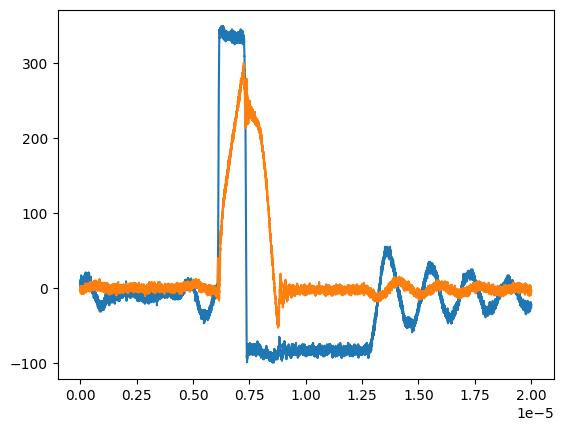

In [99]:
df= pd.read_csv("2026-01-03_20-43-43-679.csv")
Ts = df.Ts .values[0]
Vp = df.CH1.values
Ip = df.CH2.values

time = np.arange(0, len(Vp)*Ts, Ts)


Ip = Ip-Ip[:200].mean()
V0corr=-21.3888
Vp=Vp-V0corr

plt.plot(time, Vp)
plt.plot(time, 1000*Ip)
Ts

In [100]:
from utils import trigger
trigger

<function utils.trigger(sig, thresh=None, transition='rise', marginI=20)>

In [101]:
riseI = trigger(Vp, transition='rise', thresh=200)
fallI = trigger(Vp, transition='fall', thresh=200)
riseI , fallI 

([3068], [3666])

598


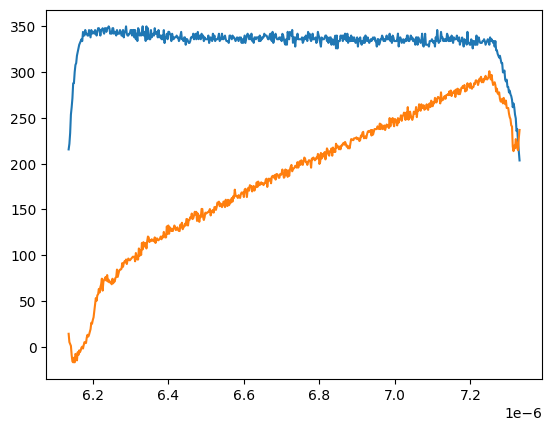

In [102]:
for (i,j) in zip(riseI , fallI ):
    plt.plot(time[i:j],Vp[i:j], c="C0")
    plt.plot(time[i:j],1e3*Ip[i:j], c="C1")
    print(j-i)

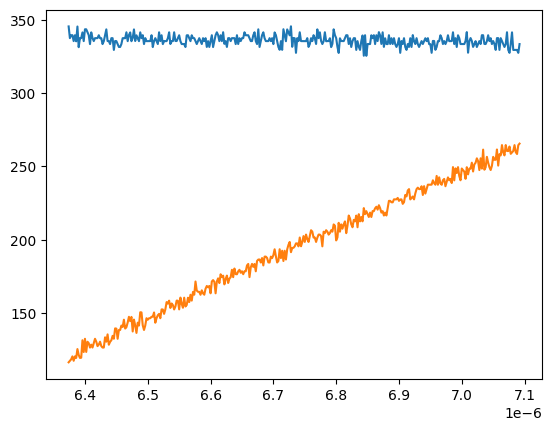

In [103]:
for (i,j) in zip(riseI , fallI ):
    N=j-i
    i=i+int(0.2*N)
    j=j-int(0.2*N)
    plt.plot(time[i:j],Vp[i:j], c="C0")
    plt.plot(time[i:j],1e3*Ip[i:j], c="C1")

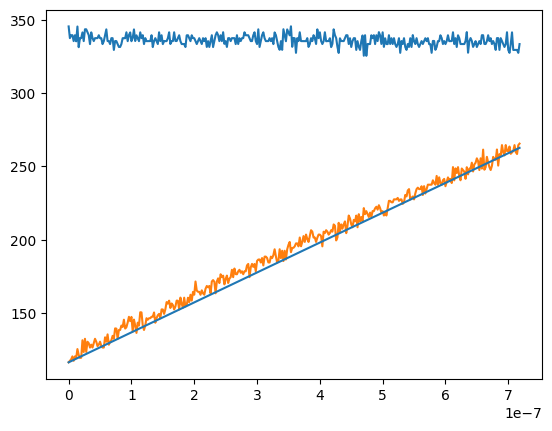

In [104]:
for (i,j) in zip(riseI , fallI ):
    N=j-i
    i=i+int(0.2*N)
    j=j-int(0.2*N)
    t=time[i:j]
    t=t-t[0]
    v=Vp[i:j]
    i=Ip[i:j]
    plt.plot(t,v, c="C0")
    plt.plot(t,1e3*i, c="C1")
    Np=26
    flux = v.cumsum()*Ts
    Lm=1650E-6
    ical=(flux )/Lm
    ical = ical -ical[0]+i[0]
    plt.plot(t,1e3*ical)

## 48V TNY 264 VS 280

In [105]:
from copy import copy 

np.float64(1e-08)

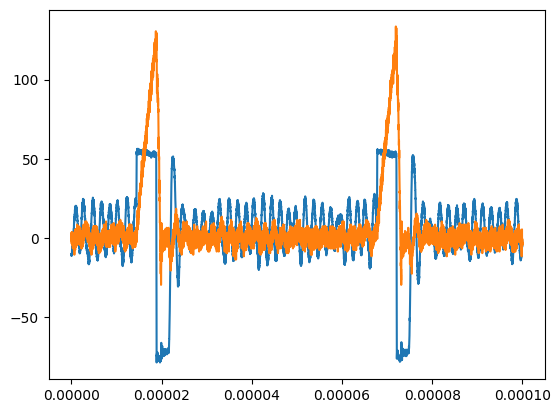

In [106]:
df= pd.read_csv("2026-01-03_20-13-08-982.csv")
Ts = df.Ts .values[0]
Vp = 47.5-df.CH4.values
Ip = df.CH2.values

time = np.arange(0, len(Vp)*Ts, Ts)


Ip = Ip-Ip[:200].mean()
#V0corr=-21.3888
#Vp=Vp-V0corr

plt.plot(time, Vp)
plt.plot(time, 1000*Ip)
Vp1 = copy(Vp)
Ip1 = copy(Ip)
time1 = copy(time)
Ts1 = copy(Ts)
Ts

np.float64(4e-08)

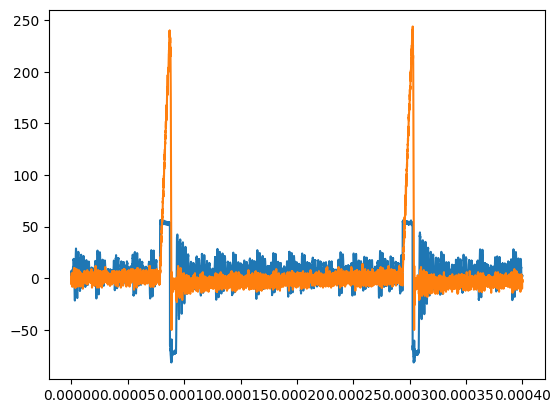

In [107]:
df= pd.read_csv("2026-01-03_20-25-49-597.csv")
Ts = df.Ts .values[0]
Vp = 47.5-df.CH4.values
Ip = df.CH2.values

time = np.arange(0, len(Vp)*Ts, Ts)


Ip = Ip-Ip[:200].mean()
#V0corr=-21.3888
#Vp=Vp-V0corr

plt.plot(time, Vp)
plt.plot(time, 1000*Ip)
Vp2 = copy(Vp)
Ip2 = copy(Ip)
time2 = copy(time)
Ts2 = copy(Ts)
Ts

In [108]:
from utils import trigger
trigger

<function utils.trigger(sig, thresh=None, transition='rise', marginI=20)>

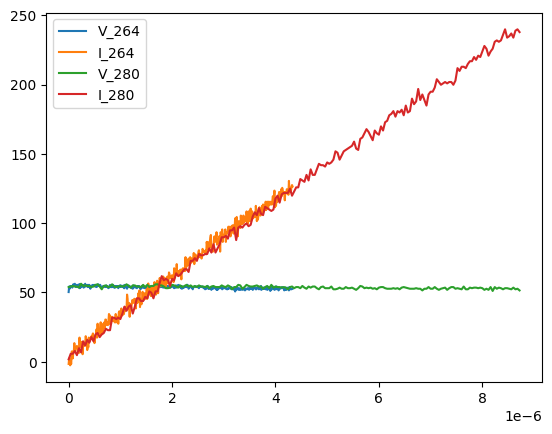

In [109]:
from utils import trigger
trigger


df= pd.read_csv("2026-01-03_20-13-08-982.csv")
Ts = df.Ts .values[0]
Vp = 47.5-df.CH4.values
Ip = df.CH2.values

time = np.arange(0, len(Vp)*Ts, Ts)


Ip = Ip-Ip[:200].mean()
#V0corr=-21.3888
#Vp=Vp-V0corr


Vp1 = copy(Vp)
Ip1 = copy(Ip)
time1 = copy(time)
Ts1 = copy(Ts)
Ts




df= pd.read_csv("2026-01-03_20-25-49-597.csv")
Ts = df.Ts .values[0]
Vp = 47.5-df.CH4.values
Ip = df.CH2.values

time = np.arange(0, len(Vp)*Ts, Ts)


Ip = Ip-Ip[:200].mean()
#V0corr=-21.3888
#Vp=Vp-V0corr

Vp2 = copy(Vp)
Ip2 = copy(Ip)
time2 = copy(time)
Ts2 = copy(Ts)
Ts



riseI = trigger(Vp1, transition='rise', thresh=50)
fallI = trigger(Vp1, transition='fall', thresh=50)

for i, j in zip (riseI , fallI ): 
    t= time1[i:j]
    t=t-t[0]
    v=  Vp1[i:j]
    ic = Ip1[i:j]
    plt.plot(t,v, label= "V_264")
    plt.plot(t, 1e3*ic, label= "I_264")
    break 

riseI = trigger(Vp2, transition='rise', thresh=50)
fallI = trigger(Vp2, transition='fall', thresh=50)

for i, j in zip (riseI , fallI ): 
    t= time2[i:j]
    t=t-t[0]
    v=  Vp2[i:j]
    ic = Ip2[i:j]
    plt.plot(t,v, label= "V_280")
    plt.plot(t, 1e3*ic, label= "I_280")
    break 
plt.legend()

## 350V TNY 264 VS 280

In [110]:
from copy import copy 

np.float64(4e-09)

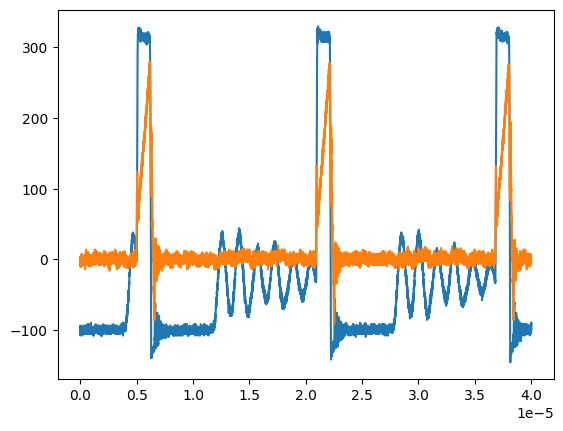

In [111]:
df= pd.read_csv("2025-12-23_08-54-28-772.csv")
Ts = df.Ts .values[0]
Vp = df.CH1.values
Ip = df.CH2.values

time = np.arange(0, len(Vp)*Ts, Ts)


Ip = Ip-Ip[:1000].mean()
#V0corr=-21.3888
#Vp=Vp-V0corr

plt.plot(time, Vp)
plt.plot(time, 1000*Ip)
Vp1 = copy(Vp)
Ip1 = copy(Ip)
time1 = copy(time)
Ts1 = copy(Ts)
Ts

np.float64(2e-09)

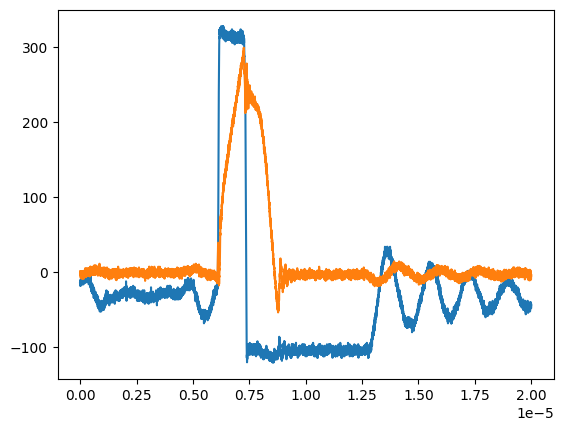

In [112]:
df= pd.read_csv("2026-01-03_20-43-43-679.csv")
Ts = df.Ts .values[0]
Vp = df.CH1.values
Ip = df.CH2.values

time = np.arange(0, len(Vp)*Ts, Ts)


Ip = Ip-Ip[:1000].mean()
#V0corr=-21.3888
#Vp=Vp-V0corr

plt.plot(time, Vp)
plt.plot(time, 1000*Ip)
Vp2 = copy(Vp)
Ip2 = copy(Ip)
time2 = copy(time)
Ts2 = copy(Ts)
Ts

In [113]:
from utils import trigger
trigger

<function utils.trigger(sig, thresh=None, transition='rise', marginI=20)>

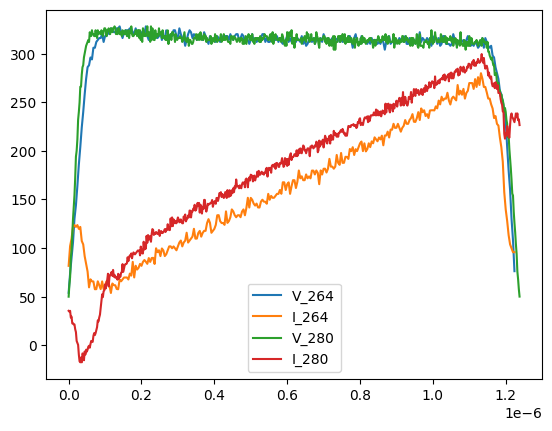

In [114]:
riseI = trigger(Vp1, transition='rise', thresh=50)
fallI = trigger(Vp1, transition='fall', thresh=50)
n= 0
for i, j in zip (riseI , fallI ): 
    t= time1[i-n:j+n]
    t=t-t[0]
    v=  Vp1[i-n:j+n]
    ic = Ip1[i-n:j+n]
    plt.plot(t,v, label= "V_264")
    plt.plot(t, 1e3*ic, label= "I_264")
    break 

riseI = trigger(Vp2, transition='rise', thresh=50)
fallI = trigger(Vp2, transition='fall', thresh=50)

for i, j in zip (riseI , fallI ): 
    t= time2[i-n:j+n]
    t=t-t[0]
    v=  Vp2[i-n:j+n]
    ic = Ip2[i-n:j+n]
    plt.plot(t,v, label= "V_280")
    plt.plot(t, 1e3*ic, label= "I_280")
    break 
plt.legend()

# Default

In [65]:
# peak each 800ms

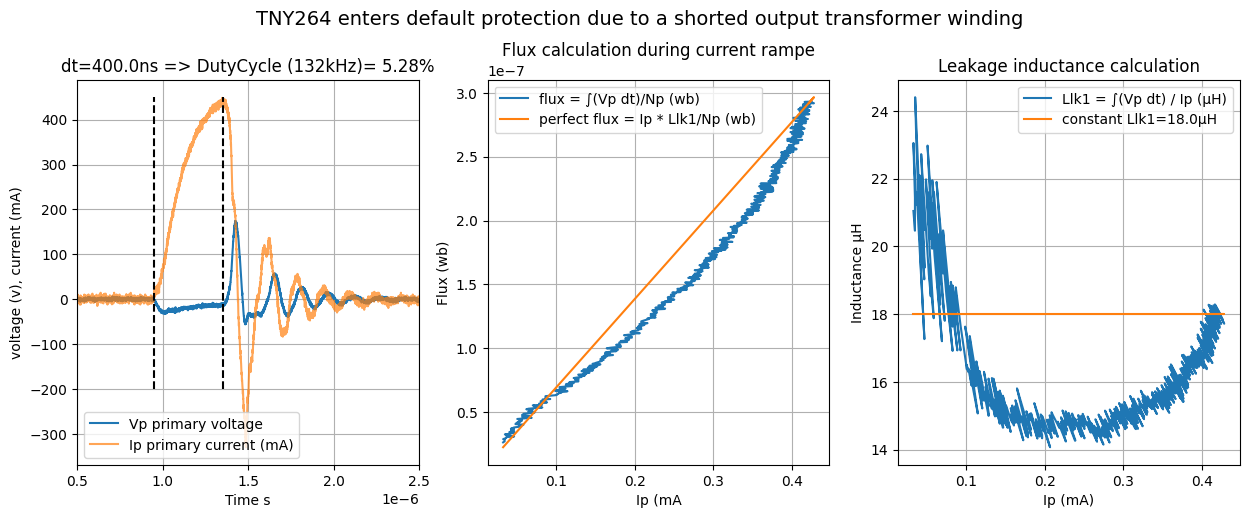

In [166]:
fig , axs = plt.subplots(1,3, figsize=(15,5))
axs = axs .flatten()



df= pd.read_csv("2026-01-04_12-16-21-026.csv")
Ts = df.Ts .values[0]
Vp = df.CH4.values
Ip = df.CH2.values

time = np.arange(0, len(Vp)*Ts, Ts)


Ip = Ip-Ip[:1000].mean()
Vp = Vp-Vp[:1000].mean()
#V0corr=-21.3888
#Vp=Vp-V0corr

axs[0].plot(time, Vp, label ="Vp primary voltage")
axs[0].plot(time, 1000*Ip, label ="Ip primary current (mA)", alpha = 0.7)
Vp1 = copy(Vp)
Ip1 = copy(Ip)
time1 = copy(time)
Ts1 = copy(Ts)



integV= -Vp.cumsum()*Ts
i= np.argmax(Ip)
t= time[:i]
i2 = Ip[:i]
intv= integV[:i]
m= i2 > 50e-3
i2 = i2 [m]-0.02
intv=intv[m] 
t=t[m]
# v = L di/dt
# L = int(v, dt)/i
Llk=18e-6
axs[1].plot(i2, intv/Np, label = "flux = ∫(Vp dt)/Np (wb)")
axs[1].plot(i2, Llk*i2/Np, label = "perfect flux = Ip * Llk1/Np (wb)")
axs[1].set_xlabel("Ip (mA")
axs[1].set_ylabel("Flux (wb)")
#axs[2].plot(i2, 1e6*intv/i2, label = "Llk1 = integral (Vp, time)/Ip (µH)")
#axs[2].plot(i2, len(i2)*[1e6*Llk], label = "constant Llk1 (µH)")

axs[2].plot(i2, 1e6*intv/i2, label="Llk1 = ∫(Vp dt) / Ip (µH)")
axs[2].plot(i2, 1e6*Llk*np.ones_like(i2), label=f"constant Llk1={1e6*Llk}µH")

#plt.plot(i2, intv)


for ax in axs:
    ax.grid()
    ax.legend()

t0=0.95e-6
t1=1.35e-6
axs[0].plot([t0,t0], [-200,450], c="k", linestyle="--")
axs[0].plot([t1,t1], [-200,450], c="k", linestyle="--")
axs[0].set_xlim([0.5e-6,2.5e-6])
axs[0].set_title(f"dt={(t1-t0)*1e9:0.1f}ns => DutyCycle (132kHz)= {1e2*(t1-t0)*132e3:0.2f}%")

axs[1].set_title("Flux calculation during current rampe")
axs[2].set_title("Leakage inductance calculation")

fig.suptitle(
    "TNY264 enters default protection due to a shorted output transformer winding",
    y=1.02,  # move slightly above the default position (default ~1.0)
    fontsize=14
)

axs[0].set_xlabel("Time s")
axs[2].set_xlabel("Ip (mA)")
axs[0].set_ylabel("voltage (v), current (mA)")
axs[2].set_ylabel("Inductance µH")


"""
t0=0.95e-6
t1=1.35e-6
axs[0].plot([t0,t0], [-200,450], c="k", linestyle="--")
axs[0].plot([t1,t1], [-200,450], c="k", linestyle="--")

"""


fig.savefig("Tny264_default.png", bbox_inches="tight")

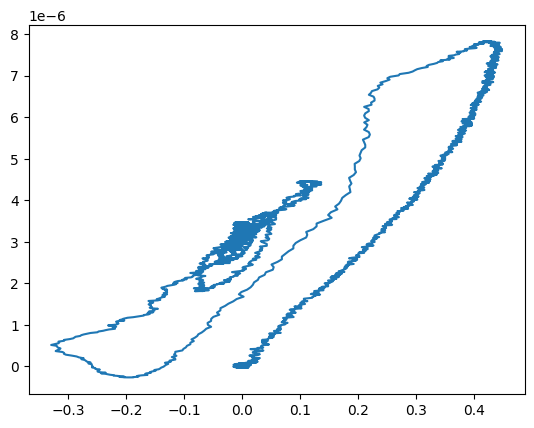

In [68]:
plt.plot(Ip, integV)

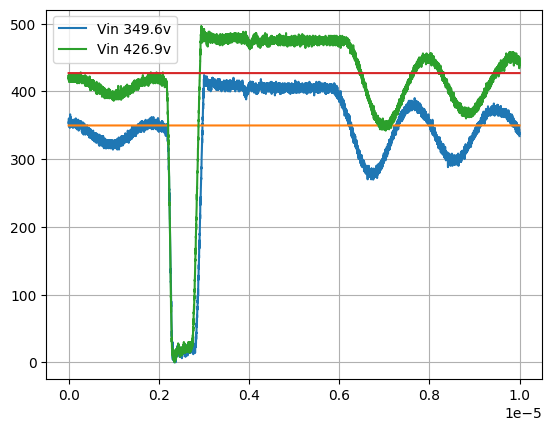

In [69]:
#349.6v
path="2026-01-04_13-09-17-582.csv"
df= pd.read_csv(path)
Ts = df.Ts .values[0]
Vp = df.CH1.values*10
Vp1= Vp-Vp.min()
time = np.arange(0, len(Vp)*Ts, Ts)
plt.plot(time, Vp1, label ="Vin 349.6v")
plt.plot(time, [349.6]*len(time))


#426.9V
path="2026-01-04_13-13-59-933.csv"
df= pd.read_csv(path)
Ts = df.Ts .values[0]
Vp = df.CH1.values*10
Vp2= Vp-Vp.min()
time = np.arange(0, len(Vp)*Ts, Ts)
plt.plot(time, Vp2, label ="Vin 426.9v")
plt.plot(time, [426.9]*len(time))
plt.legend()
plt.grid()

In [70]:
from utils import *

In [71]:
trigger

<function utils.trigger(sig, thresh=None, transition='rise', marginI=20)>

548.0 ns
486.0 ns


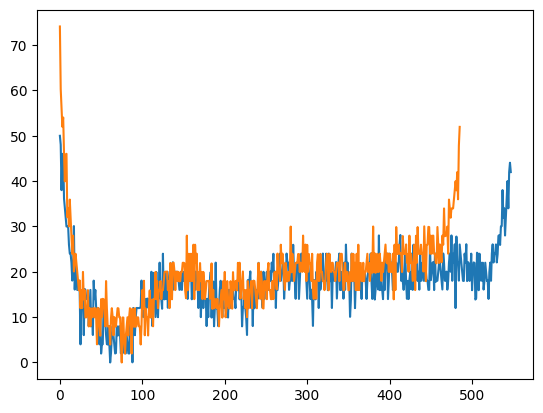

In [72]:
n= 40
n2 = 80


j= trigger(Vp1, transition='rise')[0]
i= trigger(Vp1, transition='fall')[0]
plt.plot(Vp1[i+n:j-n2])
dt1 = Ts*(j-n2 - (i+n))
print(dt1*1e9, "ns")

j= trigger(Vp2, transition='rise')[0]
i= trigger(Vp2, transition='fall')[0]
plt.plot(Vp2[i+n:j-n2])
dt2 = Ts*(j-n2 - (i+n))
print(dt2*1e9, "ns")


495.0 ns
424.99999999999994 ns


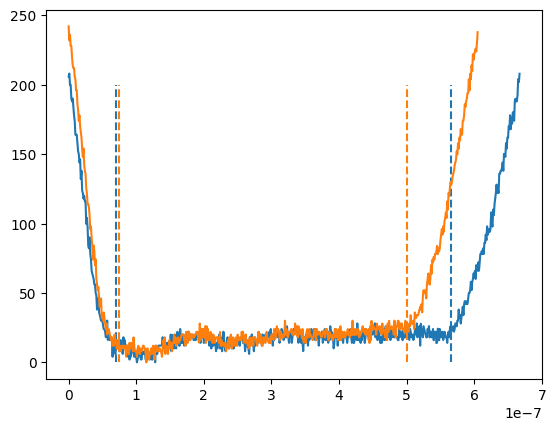

In [73]:
n= n2=0


j= trigger(Vp1, transition='rise')[0]
i= trigger(Vp1, transition='fall')[0]
v= Vp1[i+n:j-n2]
t= np.arange(0,len(v)*Ts, Ts)
plt.plot(t,v,c="C0")

t1=0.7e-7
t2= 5.65e-7
plt.plot([t1,t1],[0,200],c="C0",linestyle= "--")
plt.plot([t2,t2],[0,200],c="C0",linestyle= "--")
dt1 = t2-t1
print(dt1*1e9, "ns")

j= trigger(Vp2, transition='rise')[0]
i= trigger(Vp2, transition='fall')[0]
v= Vp2[i+n:j-n2]
t= np.arange(0,len(v)*Ts, Ts)
plt.plot(t,v,c="C1")

t1=0.75e-7
t2= 5e-7
plt.plot([t1,t1],[0,200],c="C1",linestyle= "--")
plt.plot([t2,t2],[0,200],c="C1",linestyle= "--")
dt2 = t2-t1
print(dt2*1e9, "ns")


In [74]:
print(dt1*1e9, "ns")
print(dt2*1e9, "ns")

V1 = 349
ipeak = 1.25*0.250
# V = L di/dt
L1 = V1/(ipeak/dt1)
print (f"{V1} V ==> {1e6*L1} uH")
V2  = 426

L2 = V2/(ipeak/dt2)
print (f"{V2} V ==> {1e6*L2} uH")

495.0 ns
424.99999999999994 ns
349 V ==> 552.816 uH
426 V ==> 579.3599999999999 uH


In [75]:
Lm=560E-6
Np =26
Al_meas= 1e9*Lm/Np**2 # nH
Al_datasheet = 5200
# we can calculate air gap

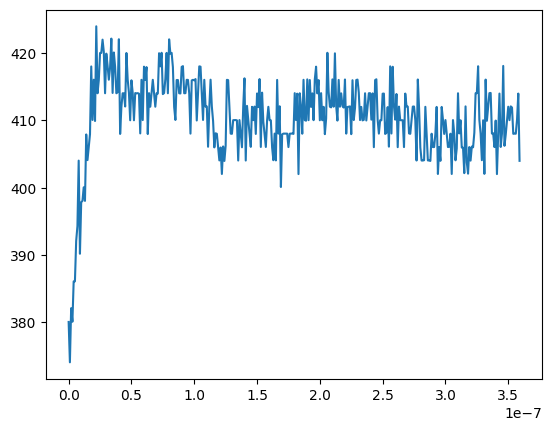

In [76]:
v= Vp1[j+140:j+500]
t= np.arange(0,len(v)*Ts, Ts)
plt.plot(t, v)

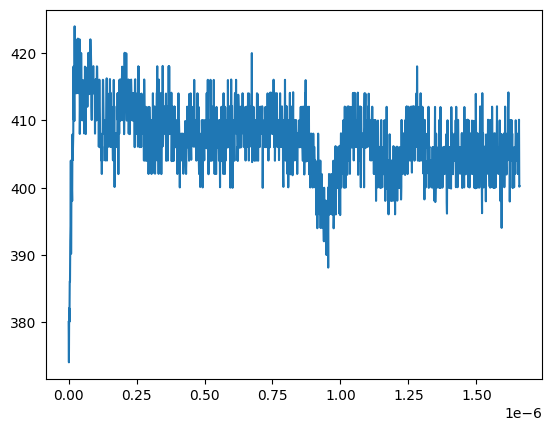

In [77]:
v= Vp1[j+140:j+1800]
t= np.arange(0,len(v)*Ts, Ts)
plt.plot(t, v)

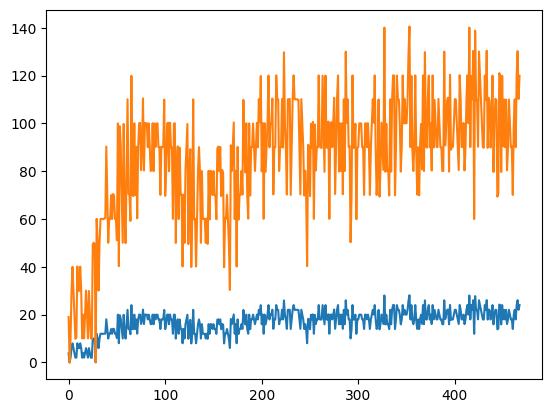

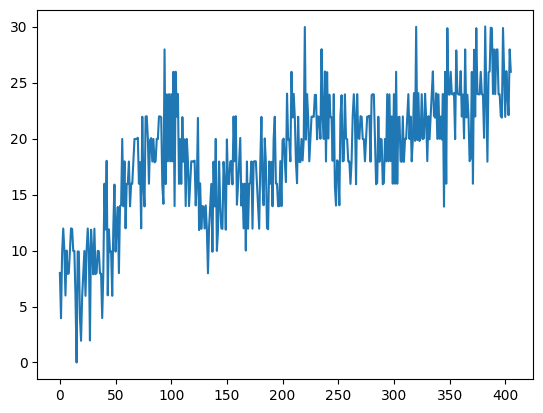

In [78]:
n=100

j= trigger(Vp1, transition='rise')[0]
i= trigger(Vp1, transition='fall')[0]
plt.plot(Vp1[i+n:j-n])
Rds=20
cur= Vp1[i+n:j-n]/Rds
plt.plot(1e2*cur)
plt.show()
j= trigger(Vp2, transition='rise')[0]
i= trigger(Vp2, transition='fall')[0]
plt.plot(Vp2[i+n:j-n])

4.300000000000001 us
166.84 uH


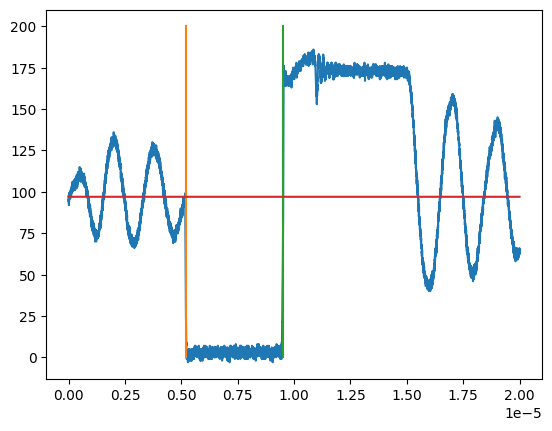

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
path="2026-01-03_20-37-01-334.csv"
df= pd.read_csv(path)
vp = df.CH1.values
vds= 97-vp
#df.plot(x="time", y= "CH1")
plt.plot(df.time, vds)
t1=0.52e-5
t2= 0.95e-5
plt.plot([t1,t1],[0,200])
plt.plot([t2,t2],[0,200])
dt= t2-t1
v= 97
time = df.time
plt.plot(time, [v]*len(time))
ic= 250e-2
#  v= L di/dt
print(dt*1e6,"us")
print(1e6*v/(ic/dt), "uH")

In [80]:
from utils import *
trigger

<function utils.trigger(sig, thresh=None, transition='rise', marginI=20)>

9.0 us
171.00000000000003 uH


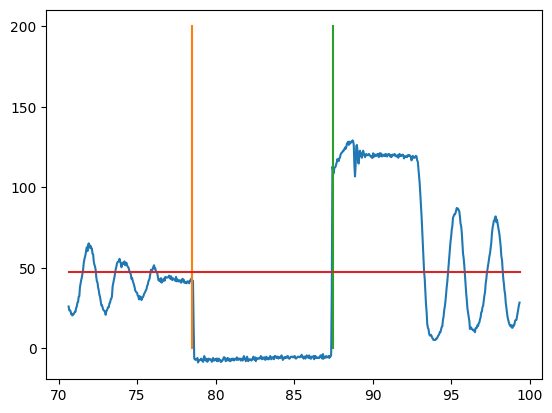

In [81]:

import pandas as pd
import matplotlib.pyplot as plt
path="2026-01-03_20-25-49-597.csv"
df= pd.read_csv(path)
vp = df.CH4.values
time = df.time.values


vin = 47.5
vds=vin-vp


i= trigger(sig= vds,  thresh=vin, transition='rise')[0]
j= trigger(sig= vds,  thresh=vin, transition='fall')[0]
vds=vp
n1, n2 =200,300
vds=vds[i-n1: j+n2]
time = time[i-n1:j+n2]

#df.plot(x="time", y= "CH1")
plt.plot(time*1e6, vds)
t1=78.5
t2= 87.5
plt.plot([t1,t1],[0,200])
plt.plot([t2,t2],[0,200])
dt= t2-t1
dt= dt*1e-6
v= vin 

plt.plot(time*1e6, [v]*len(time))
ic= 250e-2
#  v= L di/dt
print(dt*1e6,"us")
print(1e6*v/(ic/dt), "uH")

### OLD DESIGNE 